<a href="https://colab.research.google.com/github/GauriNehe/goldman-sachs-stock-prediction/blob/main/goldman-sachs-stock-prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance --quit

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: --quit


In [ ]:
#downloading the 5 years data of Goldman Sachs
ticker="GS"
data=yf.download(ticker,start="2020-01-01",end="2027-09-27")
data.head()

/tmp/ipykernel_436/2653202915.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(ticker,start="2020-01-01",end="2027-09-27")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GS,GS,GS,GS,GS
Date,,,,,
2020-01-02,200.251328,200.524795,196.696163,197.414029,3736300
2020-01-03,197.909668,198.789911,196.815773,197.926764,2274500
2020-01-06,199.935120,199.994948,196.123583,196.499599,3329300
2020-01-07,201.251144,203.199645,200.627273,200.832383,5255200
2020-01-08,203.191177,204.891849,201.242676,201.413595,3564700


In [ ]:
print(data.shape)
print(data.info)
data.describe()

(1692, 5)
<bound method DataFrame.info of Price            Close        High         Low        Open   Volume
Ticker              GS          GS          GS          GS       GS
Date                                                               
2020-01-02  200.251328  200.524795  196.696163  197.414029  3736300
2020-01-03  197.909668  198.789911  196.815773  197.926764  2274500
2020-01-06  199.935120  199.994948  196.123583  196.499599  3329300
2020-01-07  201.251144  203.199645  200.627273  200.832383  5255200
2020-01-08  203.191177  204.891849  201.242676  201.413595  3564700
...                ...         ...         ...         ...      ...
2026-09-21  959.390015  962.219971  942.619995  956.500000  1863000
2026-09-22  949.489990  967.760010  936.780029  967.390015  2052500
2026-09-23  936.359985  954.979980  933.679993  940.729980  2131500
2026-09-24  923.289978  933.409973  914.679993  931.000000  2352600
2026-09-25  935.450012  935.830017  915.299988  927.500000  1955500

[1692

Price,Close,High,Low,Open,Volume
Ticker,GS,GS,GS,GS,GS
count,1692.000000,1692.000000,1692.000000,1692.000000,1.692000e+03
mean,435.268821,440.315863,429.991893,435.156102,2.590399e+06
std,241.206149,244.370217,238.038272,241.446965,1.280344e+06
min,116.051445,122.044471,112.508938,116.962864,4.601000e+05
25%,290.684875,294.969576,288.097896,291.976102,1.792325e+06
50%,335.384796,339.082978,331.485782,335.460225,2.287400e+06
75%,551.475571,556.739421,545.832450,553.784644,3.024550e+06
max,1146.455078,1148.365764,1111.954128,1142.822964,1.444830e+07


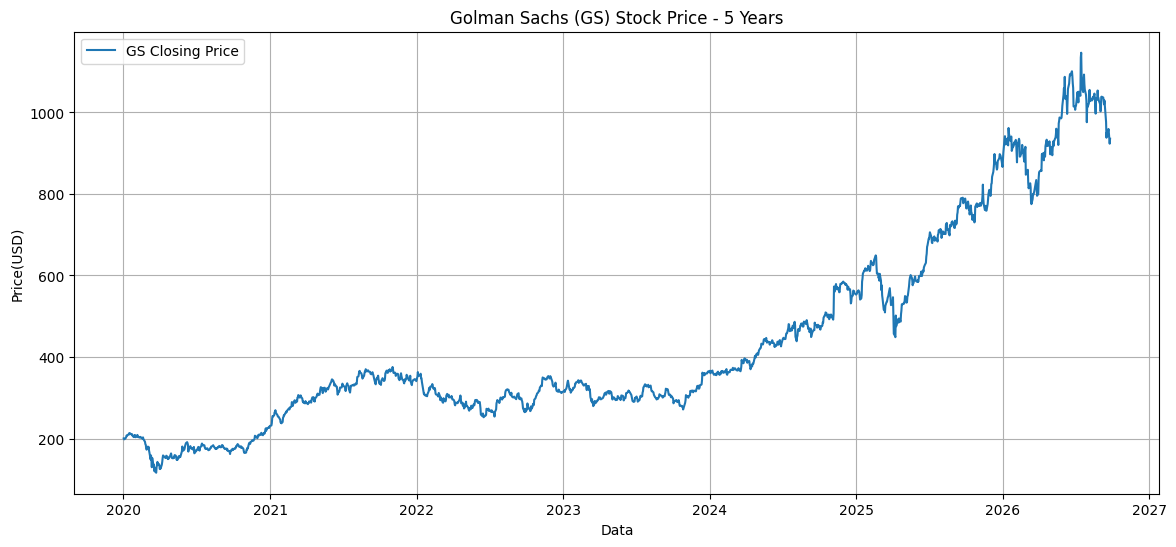

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(data['Close'],label='GS Closing Price')
plt.title('Golman Sachs (GS) Stock Price - 5 Years')
plt.xlabel('Data')
plt.ylabel('Price(USD)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#feature engineering
#create moving averages as feature
data['MA7']=data['Close'].rolling(window=7).mean()
data['MA30']=data['Close'].rolling(window=30).mean()

#previous day closing price
data['Prev_Close']=data['Close'].shift(1)

#next day closing price(prediction)
data['Target']=data['Close'].shift(-1)

#drop rows with missing values
data_model=data.dropna()

data_model.head()

Price,Close,High,Low,Open,Volume,MA7,MA30,Prev_Close,Target
Ticker,GS,GS,GS,GS,GS,,,,
Date,,,,,,,,,
2020-02-13,203.695328,204.225179,202.174130,203.268025,1461300,204.487684,206.015037,203.951706,202.610016
2020-02-14,202.610016,204.259399,201.883595,203.344978,1718700,203.606221,206.093660,203.695328,199.302673
2020-02-18,199.302673,202.601453,197.584907,202.157054,2736500,202.555056,206.140093,202.610016,202.823624
2020-02-19,202.823624,203.225289,199.362467,200.832390,2207100,202.473251,206.236377,199.302673,198.892456
2020-02-20,198.892456,202.456162,197.627643,202.037413,3183700,201.907992,206.157754,202.823624,197.089233


In [ ]:
#train_test_split
#define feature(x) and target(y)
features=['Close','MA7','MA30','Prev_Close']
X = data_model[features]
y = data_model['Target']

#split into train and test sets(80%train,20% test)
#shuffle=False because its time-series data --order matters!
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, shuffle=False)

print("Training samples:",X_train.shape[0])
print("Testing samples:",X_test.shape[0])

Training samples: 1329
Testing samples: 333


In [ ]:
#model training
#create and train the LinearRegression model
model=LinearRegression()
model.fit(X_train,y_train)

#Make predictions on test data
y_pred=model.predict(X_test)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
#checking the acccuracy
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print(f"RMSE:{rmse:.2f}")
print(f"R-squared score:{r2:.4f}")

RMSE:17.22
R-squared score:0.9832


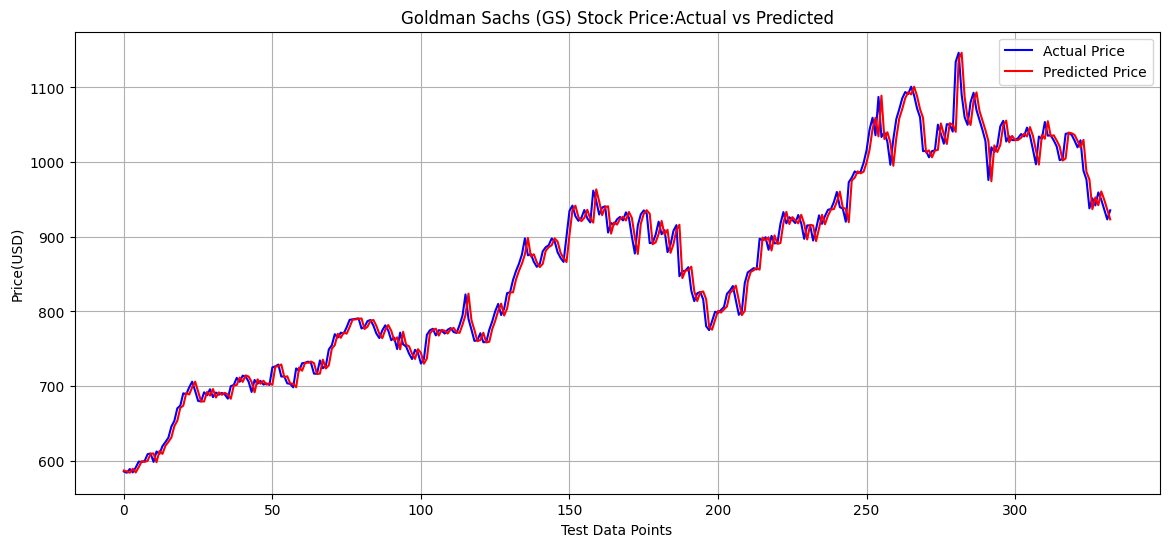

In [ ]:
#plot the actual vs predicted prices
plt.figure(figsize=(14,6))
plt.plot(y_test.values, label='Actual Price', color='blue')
plt.plot(y_pred, label='Predicted Price', color='red')
plt.title('Goldman Sachs (GS) Stock Price:Actual vs Predicted')
plt.xlabel('Test Data Points')
plt.ylabel('Price(USD)')
plt.legend()
plt.grid(True)
plt.show()